In [39]:
# ============================================================
# 1. Environment setup  --  MUST run before anything imports paddle
# ============================================================
import importlib.util
import os
import subprocess
import sys

# CPU-only flags: disable PIR + oneDNN/MKLDNN to avoid the known CPU
# inference issue. Harmless (ignored) when running on GPU.
os.environ["FLAGS_enable_pir_api"] = "0"
os.environ["FLAGS_use_mkldnn"] = "0"
os.environ["PADDLE_PDX_ENABLE_MKLDNN_BYDEFAULT"] = "0"

# Install only what is missing -- a no-op on a machine that already has them.
for pkg, mod in [("opencv-python", "cv2"), ("pandas", "pandas"),
                 ("paddleocr", "paddleocr")]:
    if importlib.util.find_spec(mod) is None:
        print(f"installing {pkg} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg],
                       check=True)

# ---------------------------------------------------------------------------
# Import order matters when torch is also installed (typical local machine).
# paddle and torch ship conflicting bundled DLLs, so on Windows:
#   import paddle -> import torch   ==  OSError [WinError 127] on shm.dll
#   import torch  -> import paddle  ==  fine
# Importing paddleocr first pins the working order for the whole session.
# ---------------------------------------------------------------------------
if "paddle" in sys.modules and "torch" not in sys.modules:
    raise RuntimeError(
        "paddle was imported before torch in this kernel -- restart the kernel "
        "and run this cell first."
    )

import paddleocr  # noqa: F401  -- MUST come before `import paddle`

print("Environment ready.")

Environment ready.


In [40]:
# ============================================================
# 2. Settings  --  the only cell you need to touch
# ============================================================

IMAGE_PATH = "newjar.png"     # <-- put your image path here

# Titles on scanned pages score between 0.25 and 0.40, so anything above ~0.4
# silently drops every paragraph_title / figure_title / image.
# Keep this low and let LAYOUT_NMS clean up the duplicates instead.
THRESHOLD  = 0.25

# Per-class override -- set to None to use the single THRESHOLD above.
# Observed class ids: 0=paragraph_title, 1=image, 2=text, 3=number, 6=figure_title
THRESHOLD_PER_CLASS = None
# THRESHOLD_PER_CLASS = {0: 0.20, 1: 0.30, 2: 0.30, 3: 0.30, 6: 0.20}

LAYOUT_NMS = True     # drops the duplicate/overlapping boxes of the same class

# Binarize the image before detection. Raw scans/renders often have a grey
# background that lowers every confidence score.
BINARIZE = True

OUTPUT_DIR = "./layout_output_image"   # results (image + json + stats) go here

_thr = THRESHOLD_PER_CLASS if THRESHOLD_PER_CLASS is not None else THRESHOLD
print(f"image={IMAGE_PATH} | threshold={_thr} | nms={LAYOUT_NMS} | "
      f"binarize={BINARIZE}")

image=newjar.png | threshold=0.25 | nms=True | binarize=True


In [41]:
# ============================================================
# 3. Load the image  (+ optional binarization)
# ============================================================
import os
import cv2

if not os.path.exists(IMAGE_PATH):
    raise FileNotFoundError(IMAGE_PATH)

os.makedirs(OUTPUT_DIR, exist_ok=True)

img = cv2.imread(IMAGE_PATH)
if img is None:
    raise ValueError(f"cv2 could not read {IMAGE_PATH} -- unsupported format?")

print(f"Loaded {IMAGE_PATH}  ({img.shape[1]} x {img.shape[0]} px)")

if BINARIZE:
    grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(
        grey, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    input_path = os.path.join(OUTPUT_DIR, "input_binary.png")
    cv2.imwrite(input_path, cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR))
    print(f"Binarized -> {input_path}")
else:
    input_path = IMAGE_PATH

print(f"Detection input: {input_path}")

Loaded newjar.png  (587 x 833 px)
Binarized -> ./layout_output_image\input_binary.png
Detection input: ./layout_output_image\input_binary.png


In [42]:
# ============================================================
# 4. Load the layout model  (once)
# ============================================================
from paddleocr import LayoutDetection

model = LayoutDetection(
    model_name="PP-DocLayout_plus-L",
    threshold=THRESHOLD_PER_CLASS if THRESHOLD_PER_CLASS is not None else THRESHOLD,
    layout_nms=LAYOUT_NMS,
)

print("Layout model loaded successfully!")

Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\ASUS\.paddlex\official_models\PP-DocLayout_plus-L`.


Layout model loaded successfully!


In [43]:
# ============================================================
# 5. Run layout detection
# ============================================================
import os

records = []  # one row per detected box

for res in model.predict(input_path, batch_size=1):
    res.save_to_img(save_path=OUTPUT_DIR)
    res.save_to_json(save_path=os.path.join(OUTPUT_DIR, "result.json"))

    # NOTE: DetResult is dict-like with the keys at the top level.
    # There is no "res" wrapper key -- that only appears in res.print().
    for box in res["boxes"]:
        x1, y1, x2, y2 = (float(v) for v in box["coordinate"])
        records.append(
            {
                "label": box["label"],
                "cls_id": box["cls_id"],
                "score": float(box["score"]),
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "width": x2 - x1,
                "height": y2 - y1,
            }
        )

print(f"Done. {len(records)} box(es) detected, results under {OUTPUT_DIR}")

Done. 36 box(es) detected, results under ./layout_output_image


./layout_output_image\input_binary_res.png


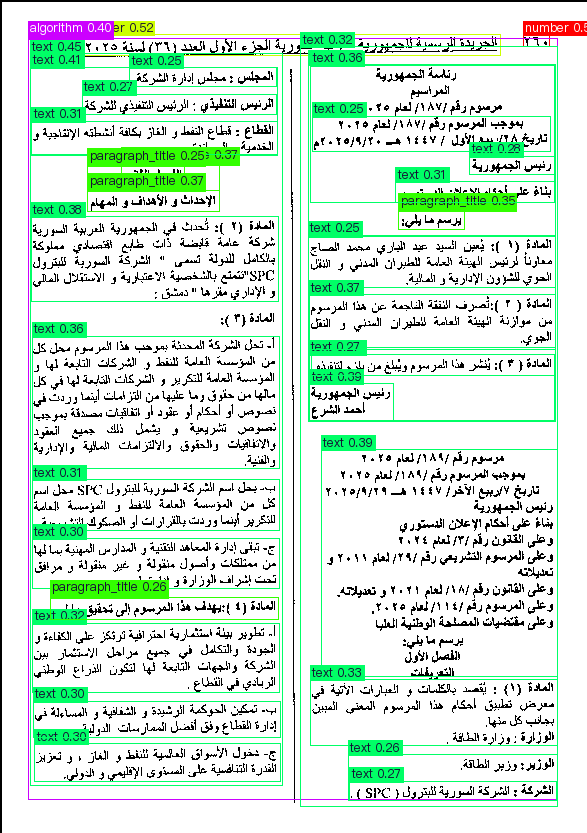

In [44]:
# ============================================================
# 6. Show the annotated result inline
# ============================================================
import glob
import os
from IPython.display import Image as IPyImage, display

annotated = [
    p for p in glob.glob(os.path.join(OUTPUT_DIR, "*.jpg"))
    + glob.glob(os.path.join(OUTPUT_DIR, "*.png"))
    if os.path.basename(p) != "input_binary.png"
]

if annotated:
    newest = max(annotated, key=os.path.getmtime)
    print(newest)
    display(IPyImage(filename=newest))
else:
    print(f"No annotated image found in {OUTPUT_DIR}")

In [45]:
# ============================================================
# 7. Width statistics
# ============================================================
import os
import pandas as pd

df = pd.DataFrame(records)

if df.empty:
    print("No boxes were detected -- try lowering THRESHOLD in the settings cell.")
else:
    # --- per label ---------------------------------------------------
    per_label = (
        df.groupby("label")["width"]
        .agg(count="count", min_width="min", max_width="max", mean_width="mean")
        .sort_values("count", ascending=False)
        .round(2)
    )

    # --- everything together, label ignored --------------------------
    overall = pd.DataFrame(
        [
            {
                "count": len(df),
                "min_width": df["width"].min(),
                "max_width": df["width"].max(),
                "mean_width": df["width"].mean(),
            }
        ],
        index=["ALL"],
    ).round(2)

    print("=== Width statistics per label ===")
    display(per_label)

    print("=== Width statistics over all boxes (label ignored) ===")
    display(overall)

    # --- save --------------------------------------------------------
    df.to_csv(os.path.join(OUTPUT_DIR, "boxes.csv"), index=False)
    per_label.to_csv(os.path.join(OUTPUT_DIR, "width_stats_per_label.csv"))
    overall.to_csv(os.path.join(OUTPUT_DIR, "width_stats_overall.csv"))

    print(f"\nSaved boxes.csv, width_stats_per_label.csv, "
          f"width_stats_overall.csv -> {OUTPUT_DIR}")

=== Width statistics per label ===


,count,min_width,max_width,mean_width
label,,,,
text,28,83.18,256.66,223.40
paragraph_title,5,63.15,228.65,124.22
algorithm,1,528.93,528.93,528.93
number,1,25.79,25.79,25.79
header,1,417.24,417.24,417.24


=== Width statistics over all boxes (label ignored) ===


,count,min_width,max_width,mean_width
ALL,36,25.79,528.93,218.01



Saved boxes.csv, width_stats_per_label.csv, width_stats_overall.csv -> ./layout_output_image


In [46]:
# ============================================================
# 8. Crop every box except the big one, then OCR each crop with EasyOCR
# ============================================================
import os
import cv2
import pandas as pd

# --- knobs -----------------------------------------------------------
BIG_BOX_AREA_FRAC = 0.5   # a box covering >= this share of the page is the
                          # whole-page container -> skipped
CROP_PAD  = 5             # px of padding around each box
OCR_LANGS = ["ar", "en"]
OCR_ON_BINARIZED = False  # False = crop from the original image (usually better)

CROPS_DIR = os.path.join(OUTPUT_DIR, "crops")
os.makedirs(CROPS_DIR, exist_ok=True)

# --- source image to crop from ---------------------------------------
src = cv2.imread(input_path if OCR_ON_BINARIZED else IMAGE_PATH)
if src is None:
    raise ValueError("could not re-read the source image for cropping")

H, W = src.shape[:2]
page_area = float(H * W)

# --- drop the big container box(es) ----------------------------------
kept = []
for i, r in enumerate(records):
    frac = ((r["x2"] - r["x1"]) * (r["y2"] - r["y1"])) / page_area
    if frac >= BIG_BOX_AREA_FRAC:
        print(f"  skipping big box #{i} ({r['label']}, {frac:.0%} of the page)")
        continue
    kept.append((i, r))

print(f"{len(kept)} of {len(records)} box(es) kept for OCR")

# --- EasyOCR reader, loaded once -------------------------------------
# easyocr pulls in torch, which is safe here because cell 1 already
# imported paddleocr (paddle before torch is the order that breaks).
import easyocr

reader = easyocr.Reader(OCR_LANGS)
print(f"EasyOCR reader ready ({'+'.join(OCR_LANGS)})\n")

# --- crop + read -----------------------------------------------------
ocr_rows = []

for i, r in kept:
    x1 = max(int(r["x1"]) - CROP_PAD, 0)
    y1 = max(int(r["y1"]) - CROP_PAD, 0)
    x2 = min(int(r["x2"]) + CROP_PAD, W)
    y2 = min(int(r["y2"]) + CROP_PAD, H)

    crop = src[y1:y2, x1:x2]
    if crop.size == 0:
        print(f"  box {i:03d} ({r['label']}): empty crop, skipped")
        continue

    crop_path = os.path.join(CROPS_DIR, f"box_{i:03d}_{r['label']}.png")
    cv2.imwrite(crop_path, crop)

    # pass the path, not the array -- easyocr's ndarray branch assumes BGR
    # while the path branch loads RGB, and the models expect RGB.
    lines = reader.readtext(crop_path)      # [(bbox, text, confidence), ...]
    text = " ".join(t for _, t, _ in lines).strip()
    conf = (sum(c for _, _, c in lines) / len(lines)) if lines else 0.0

    ocr_rows.append(
        {
            "box": i,
            "label": r["label"],
            "det_score": round(r["score"], 3),
            "n_lines": len(lines),
            "ocr_conf": round(conf, 3),
            "text": text,
            "crop": crop_path,
        }
    )

    print(f"--- box {i:03d}  {r['label']}  "
          f"({len(lines)} line(s), conf {conf:.2f}) ---")
    print(text if text else "(no text found)")
    print()

# --- save ------------------------------------------------------------
ocr_df = pd.DataFrame(ocr_rows)

if ocr_df.empty:
    print("No crops were OCR'd.")
else:
    display(ocr_df[["box", "label", "det_score", "n_lines", "ocr_conf", "text"]])

    ocr_df.to_csv(os.path.join(OUTPUT_DIR, "ocr_results.csv"), index=False)

    txt_path = os.path.join(OUTPUT_DIR, "ocr_results.txt")
    with open(txt_path, "w", encoding="utf-8") as f:
        for row in ocr_rows:
            f.write(f"[box {row['box']:03d} | {row['label']}]\n")
            f.write(row["text"] + "\n\n")

    print(f"Saved ocr_results.csv + ocr_results.txt -> {OUTPUT_DIR}")
    print(f"Crops -> {CROPS_DIR}")

  skipping big box #4 (algorithm, 82% of the page)
35 of 36 box(es) kept for OCR


EasyOCR reader ready (ar+en)

--- box 000  number  (0 line(s), conf 0.00) ---
(no text found)

--- box 001  header  (1 line(s), conf 0.10) ---
لاجتبدر

--- box 002  text  (102 line(s), conf 0.48) ---
مجلس إدارة الشركة الرنيس التنيذي للثركة الرنيس التنفيذي بكاذة انشطته الإئتاجبة فطاع النفل النطاع المساندآ . الخدمية الاهداف الإحداث (: تحدث في الجمهورية العربية السورية الملاا مسوكة ذات قااطة عامة سركة الشركة  السوربة بالكامل   للدولة الاستتلال 3PC "نتمتع بالشخصية الاعتبارية دسشق الإداري سترها المادة معل كل - تحل الشركة المحدئة بمرجب دذا الشركات التابعة لها العامة للننمل الشركات العامة للتكرير مالها من حقوق وما عايها من التزامات أيتما وردت في اتفاقيات مصدفة بسوجب عفود ادكام نسوس العتود جميع بتس تسريعية تموص المالية   والإدارية والحفوق   والالتزامات والاتفافيات والفنية SFC بحل اسم الشركة السوربة للترول لل اسم الموسسة المامة كل من الصكوك التشريعية آبنما وردت بالقرارات السهنبة بسا لبا تتى إدارة المعاهد التتنية مر اذق عير سدقولة سن سمتلكات وأصول منتولة تحت إشراف الوزارة و إدارتها إلى تدقرقق ما

,box,label,det_score,n_lines,ocr_conf,text
0,0,number,0.552,0,0.000,
1,1,header,0.521,1,0.097,لاجتبدر
2,2,text,0.450,102,0.475,مجلس إدارة الشركة الرنيس التنيذي للثركة الرنيس...
3,3,text,0.412,8,0.594,مجلس إدارة الشركة المبلس الرئيس التنفيذي : الر...
4,5,text,0.392,26,0.499,مرسوم رقم /٨٩ ١ لعام رقم ٨٩٨ ٧١ لعام بمو جب ال...
5,6,text,0.391,4,0.501,الجمهوربة احها رلبس الشرع
6,7,text,0.378,20,0.517,الجسهوربة العرببة الصورية تعدث الفلاا مسوكة طا...
7,8,text,0.377,10,0.557,البار المادة الناج معاونا لرنيس الهينة العامة ...
8,9,text,0.376,36,0.466,رئاسة الجمهورية مرسوم رقم ٨٧٨ ١ لعام بموجب الم...
9,10,text,0.374,8,0.446,الناجسة عن حذا المرسوم [:تصرف المادد النقل للط...


Saved ocr_results.csv + ocr_results.txt -> ./layout_output_image
Crops -> ./layout_output_image\crops
